In [1]:
from utils.dependencies import *;

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import ComputeMultiplicity as cm
test_data = Table.read("./massive_data/synthetic_data_25000.fits")
sc_cube = pickle.load(open("./data/08_05_27_sc_cube_singular.pkl", "rb"))
soltypes = [0,5,7,9,12]
test_data["soltype_index"] = [soltypes.index(t["solution_type"]) for t in test_data]

### Test

In [9]:
INDEX = 0
reference_object = test_data[INDEX:INDEX+1].copy()
reference_object[0]["mass"] = 0.2
reference_object[0]["soltype_index"] = 2
reference_object[0]["phot_g_mean_mag"] = 13
print(reference_object[0][["soltype_index", "phot_g_mean_mag", "parallax", "mass"]])
grid_shape = (50,50)
p_range, q_range = (1,8), (0.05, 0.5)
p_boundaries = np.linspace(*p_range, grid_shape[0]+1)
q_boundaries = np.linspace(*q_range, grid_shape[1]+1)
grid = cm.compute_grid(target_object=reference_object[0], sc_cube=sc_cube, period_boundaries=p_boundaries, m_boundaries=q_boundaries, scale=5)

reference_object[0]["phot_g_mean_mag"] = 17
print(reference_object[0][["solution_type", "phot_g_mean_mag", "parallax", "mass"]])
grid_dim = cm.compute_grid(target_object=reference_object[0], sc_cube=sc_cube, period_boundaries=p_boundaries, m_boundaries=q_boundaries, scale=5)

soltype_index phot_g_mean_mag     parallax    mass
------------- --------------- --------------- ----
            2            13.0 9.3551807699566  0.2
solution_type phot_g_mean_mag     parallax    mass
------------- --------------- --------------- ----
            0            17.0 9.3551807699566  0.2


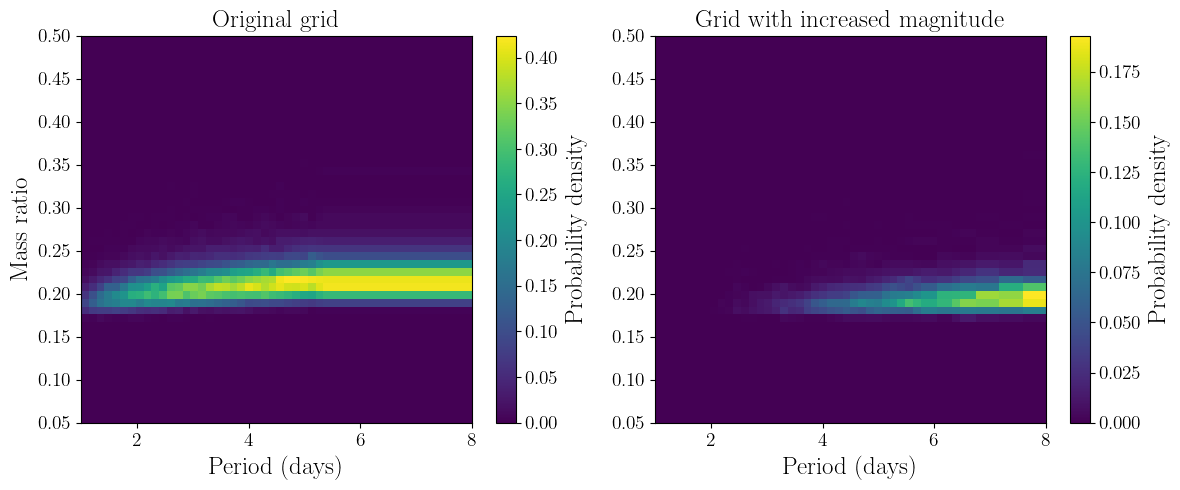

In [10]:
fig, axs = plt.subplots(1,2, figsize=(12,5))
ax = axs[0]
im1 = ax.imshow(grid, origin="lower", aspect="auto", extent=(p_boundaries[0], p_boundaries[-1], q_boundaries[0], q_boundaries[-1]))
ax.set_title("Original grid")
ax.set_xlabel("Period (days)")
ax.set_ylabel("Mass ratio")
fig.colorbar(im1, ax=ax, label="Probability density")

ax = axs[1]
im2 = ax.imshow(grid_dim, origin="lower", aspect="auto", extent=(p_boundaries[0], p_boundaries[-1], q_boundaries[0], q_boundaries[-1]))
ax.set_title("Grid with increased magnitude")
ax.set_xlabel("Period (days)")
fig.colorbar(im2, ax=ax, label="Probability density")
plt.tight_layout()

# Synthdata

In [ ]:
real_fb = len(test_data[test_data["is_binary"]])/len(test_data)

0.30516


In [ ]:
reduced_memory = test_data[["soltype_index", "solution_type", "phot_g_mean_mag", "parallax", "mass", "q_max"]]
model_cube = cm.create_model_cube(grid_shape=(50,35), p_model=(4,1.3), q_model=0)
fbs, likelihoods = cm.multiplicity(catalogue=reduced_memory, model_cube=model_cube, sc_cube=sc_cube, resolution=1000, cutoff=np.exp(-30), scale=5, verbose=True)

Computing grids...:   0%|          | 0/25000 [00:00<?, ?it/s]

Computing likelihoods...:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
cut = 2

relative_likelihoods = likelihoods - np.max(likelihoods)

peakdx = np.argmax(likelihoods)
max_fb = fbs[peakdx]    
minus_loc = fbs[:peakdx][np.argmin(abs(relative_likelihoods[:peakdx]+cut))]   
plus_loc = fbs[peakdx:][np.argmin(abs(relative_likelihoods[peakdx:]+cut))]  

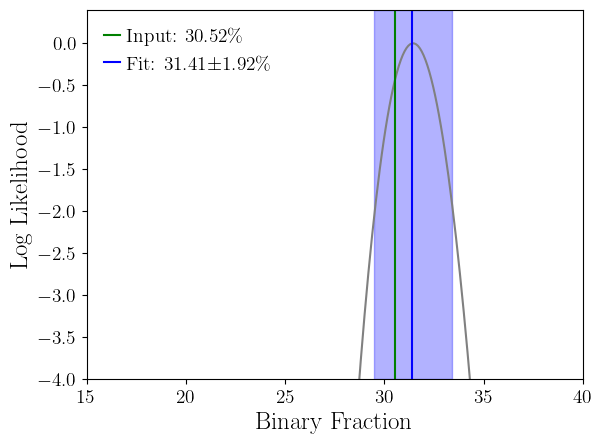

In [35]:
plt.plot(fbs*100, likelihoods-np.max(likelihoods), color="grey");
plt.axvline(real_fb*100, color="green", label=f"Input: {real_fb*100:.2f}\%");
plt.axvline(max_fb*100, color="blue", label=f"Fit: {max_fb*100:.2f}$\pm${(max_fb-minus_loc)*100:.2f}\%");
plt.axvspan(minus_loc*100, plus_loc*100, color="blue", alpha=0.3);
plt.xlabel("Binary Fraction");
plt.ylabel("Log Likelihood");
plt.legend();
plt.xlim([15,40]);
plt.ylim([-4,0.4]);

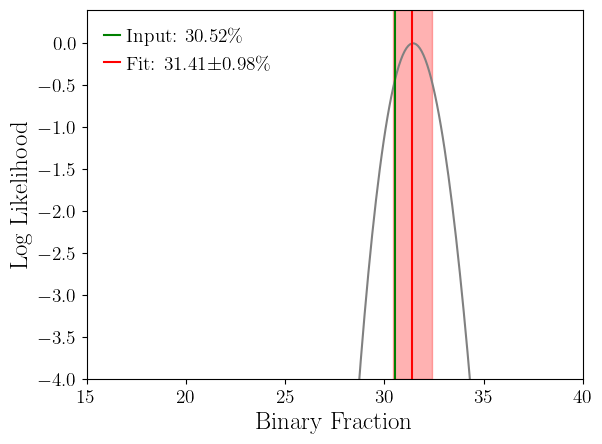

In [34]:
sigma = cm.fisher_uncertainty(likelihoods)[0]
max_fb = fbs[np.argmax(likelihoods)]
plt.plot(fbs*100, likelihoods-np.max(likelihoods), color="grey");
plt.axvline(real_fb*100, color="green", label=f"Input: {real_fb*100:.2f}\%");
plt.axvline(max_fb*100, color="red", label=f"Fit: {max_fb*100:.2f}$\pm${sigma*100:.2f}\%");
plt.axvspan(max_fb*100-sigma*100, max_fb*100+sigma*100, color="red", alpha=0.3);
plt.xlabel("Binary Fraction");
plt.ylabel("Log Likelihood");
plt.legend();
plt.xlim([15,40]);
plt.ylim([-4,0.4]);

In [3]:
model_cube = cm.create_model_cube(grid_shape=(50,35), p_model=(4,1.3), q_model=0)

small_objects = test_data[test_data["mass"] < 0.35][["solution_type", "phot_g_mean_mag", "parallax", "mass", "q_max"]]
fbs_small, likelihoods_small = cm.multiplicity(catalogue=small_objects, model_cube=model_cube, sc_cube=sc_cube, resolution=1000, cutoff=np.exp(-30), scale=5, verbose=True)

big_objects = test_data[test_data["mass"] > 0.35][["solution_type", "phot_g_mean_mag", "parallax", "mass", "q_max"]]
fbs_big, likelihoods_big = cm.multiplicity(catalogue=big_objects, model_cube=model_cube, sc_cube=sc_cube, resolution=1000, cutoff=np.exp(-30), scale=5, verbose=True)

Computing grids:   0%|          | 0/13097 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing grids:   0%|          | 0/11903 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

In [4]:
def uncertainty(likelihoods, fbs, cut=2):
    relative_likelihoods = likelihoods - np.max(likelihoods)

    peakdx = np.argmax(likelihoods)
    max_fb = fbs[peakdx]    
    minus_loc = fbs[:peakdx][np.argmin(abs(relative_likelihoods[:peakdx]+cut))]   
    plus_loc = fbs[peakdx:][np.argmin(abs(relative_likelihoods[peakdx:]+cut))]  
    return max_fb, minus_loc, plus_loc

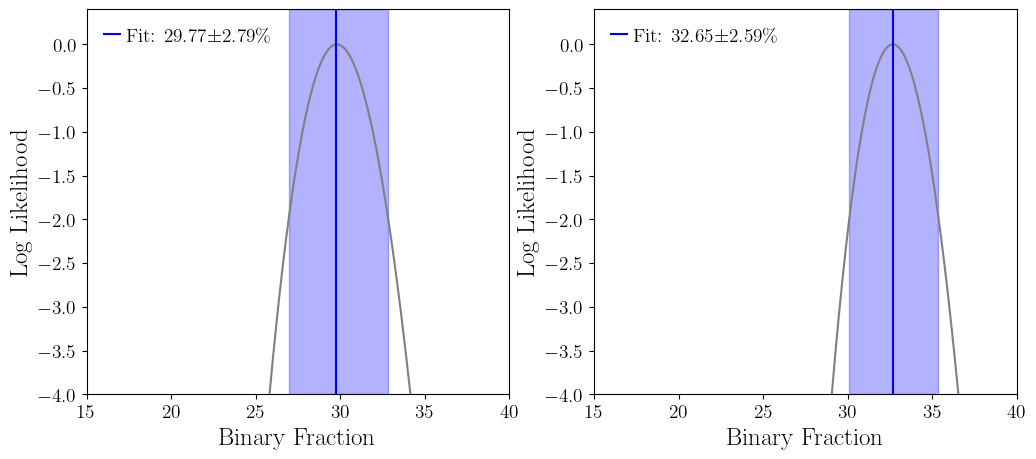

In [8]:
small_uncertainties = uncertainty(likelihoods_small, fbs_small)
big_uncertainties = uncertainty(likelihoods_big, fbs_big)

fig, axs = plt.subplots(1,2, figsize=(12,5))
ax = axs[0]
#real_fb = len(small_objects[small_objects["is_binary"]])/len(small_objects)
max_fb, minus_loc, plus_loc = small_uncertainties
ax.plot(fbs_small*100, likelihoods_small-np.max(likelihoods_small), color="grey");
#ax.axvline(real_fb*100, color="green", label=f"Input: {real_fb*100:.2f}\%");
ax.axvline(max_fb*100, color="blue", label=f"Fit: {max_fb*100:.2f}$\pm${(max_fb-minus_loc)*100:.2f}\%");
ax.axvspan(minus_loc*100, plus_loc*100, color="blue", alpha=0.3);
ax.set_xlabel("Binary Fraction");
ax.set_ylabel("Log Likelihood");
ax.legend();
ax.set_xlim([15,40]);
ax.set_ylim([-4,0.4]);

ax = axs[1]
#real_fb = len(big_objects[big_objects["is_binary"]])/len(big_objects)
max_fb, minus_loc, plus_loc = big_uncertainties
ax.plot(fbs_big*100, likelihoods_big-np.max(likelihoods_big), color="grey");
#ax.axvline(real_fb*100, color="green", label=f"Input: {real_fb*100:.2f}\%");
ax.axvline(max_fb*100, color="blue", label=f"Fit: {max_fb*100:.2f}$\pm${(max_fb-minus_loc)*100:.2f}\%");
ax.axvspan(minus_loc*100, plus_loc*100, color="blue", alpha=0.3);
ax.set_xlabel("Binary Fraction");
ax.set_ylabel("Log Likelihood");
ax.legend();
ax.set_xlim([15,40]);
ax.set_ylim([-4,0.4]);

In [9]:
asp_import("synthetic_ms_candidates", "sd")
REF_FRACTIONS = (0.25, 0.5)
MASS_RANGE = (0.2, 0.45)
def bin_frac(m):
    sep = (m - MASS_RANGE[0]) / (MASS_RANGE[1] - MASS_RANGE[0])
    return sep * (REF_FRACTIONS[1] - REF_FRACTIONS[0]) + REF_FRACTIONS[0]

In [10]:
mdwarfs = Table.read('./data/06_05_26_final_table.fits', format='fits')
reduced_mdwarfs = mdwarfs[["ra", "dec", "pmra", "pmdec", "parallax", "phot_g_mean_mag", "bp_rp", "mass_single", "mh_single", "q_max"]]

In [12]:
res = sd.create_synthetic_data(object_count=100000, catalogue=reduced_mdwarfs, binarity_model=bin_frac, period_model=(4,1.3), mass_model=0, ecc_type="turnover", return_ruwe=True, return_fits=False)

Computing Singles:   0%|          | 0/60436 [00:00<?, ?it/s]

Computing Binaries:   0%|          | 0/39564 [00:00<?, ?it/s]

In [13]:
likelihoods = []
masses = res["mass"]
bins = 5
percs = np.percentile(masses, np.linspace(0,100,bins+1))
for i in range(bins):
    subset = res[(res["mass"] >= percs[i]) & (res["mass"] < percs[i+1])]
    reduced_memory = subset[["solution_type", "phot_g_mean_mag", "parallax", "mass", "q_max", "is_binary"]]
    model_cube = cm.create_model_cube(grid_shape=(50,35), p_model=(4,1.3), q_model=0)
    fbs, likelihoods_bin = cm.multiplicity(catalogue=reduced_memory, model_cube=model_cube, sc_cube=sc_cube, resolution=1000, cutoff=np.exp(-30), scale=5, verbose=True)
    likelihoods.append(likelihoods_bin)

Computing grids:   0%|          | 0/20000 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing grids:   0%|          | 0/20000 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing grids:   0%|          | 0/20000 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing grids:   0%|          | 0/20000 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing grids:   0%|          | 0/19999 [00:00<?, ?it/s]

Computing likelihoods:   0%|          | 0/1000 [00:00<?, ?it/s]

In [15]:
def uncertainty(likelihoods, cut=2):
    fbs = np.linspace(0.02, 0.98, len(likelihoods))
    relative_likelihoods = likelihoods - np.max(likelihoods)

    peakdx = np.argmax(likelihoods)
    max_fb = fbs[peakdx]    
    sigma = max_fb - fbs[:peakdx][np.argmin(abs(relative_likelihoods[:peakdx]+cut))]
    return max_fb, sigma

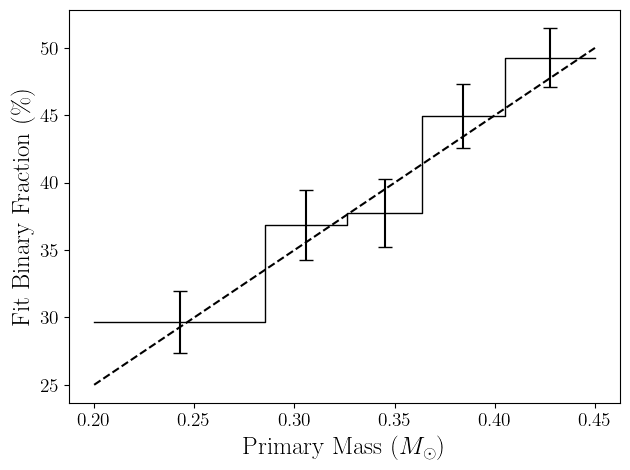

In [ ]:
mass_lims_b = np.clip(percs, None, 0.45)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
synth_results = np.array([uncertainty(l) for l in likelihoods])

plt.errorbar(bin_centers, synth_results[:,0]*100, yerr=(synth_results[:,1]*100), fmt='none', capsize=5, ecolor='k', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*synth_results[:,0]).repeat(2), c="k", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(f"Fit Binary Fraction (\%)");

ms = np.linspace(0.2,0.45,100)
REF_FRACTIONS = (0.25, 0.5)
MASS_RANGE = (0.2, 0.45)
def bin_frac(m):
    sep = (m - MASS_RANGE[0]) / (MASS_RANGE[1] - MASS_RANGE[0])
    return sep * (REF_FRACTIONS[1] - REF_FRACTIONS[0]) + REF_FRACTIONS[0]
plt.plot(ms, bin_frac(ms)*100, c="k", linestyle="--", zorder=0);

plt.tight_layout();
#plt.savefig("./plots/synthbinarity.pdf", dpi=800, transparent=True)

In [45]:
len(res[res["is_binary"]])/len(res)

0.39564

In [44]:
print_table(res)

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,95.04,2.80,0.56,0.09,1.51
Counts,100000,95043,2803,557,90,1506


# Real Data

In [55]:
print_table(mdwarfs[mdwarfs["flux_ratio_mean"] < 10**(-1.5)])

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.12,3.46,0.19,0.10,0.13
Counts,253085,243269,8755,484,252,325


In [56]:
print_table(mdwarfs[mdwarfs["flux_ratio_mean"] > 10**(-1.5)])

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,92.58,6.99,0.23,0.07,0.12
Counts,129924,120280,9080,305,97,162


In [88]:
print_table(mdwarfs)

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,94.92,4.66,0.21,0.09,0.13
Counts,383009,363549,17835,789,349,487


In [3]:
mdwarfs = Table.read('./data/06_05_26_final_table.fits', format='fits')
reduced_mdwarfs = mdwarfs[["solution_type", "parallax", "phot_g_mean_mag", "mass", "q_max"]]

In [ ]:
data_likelihoods = []
masses = reduced_mdwarfs["mass"]
bins = 15
percs = np.percentile(masses, np.linspace(0,100,bins+1))
for i in range(bins):
    subset = reduced_mdwarfs[(reduced_mdwarfs["mass"] >= percs[i]) & (reduced_mdwarfs["mass"] < percs[i+1])]
    reduced_memory = subset[["solution_type", "phot_g_mean_mag", "parallax", "mass", "q_max"]]
    model_cube = cm.create_model_cube(grid_shape=(50,35), p_model=(4,1.3), q_model=0)
    fbs, likelihoods_bin = cm.multiplicity(catalogue=reduced_memory, model_cube=model_cube, sc_cube=sc_cube, resolution=1000, cutoff=np.exp(-30), scale=5, verbose=True)
    data_likelihoods.append(likelihoods_bin)

In [36]:
output = {
    "likelihoods": data_likelihoods,
}
pickle.dump(output, open("./data/13_05_26_likelihoods.pkl", "wb"))

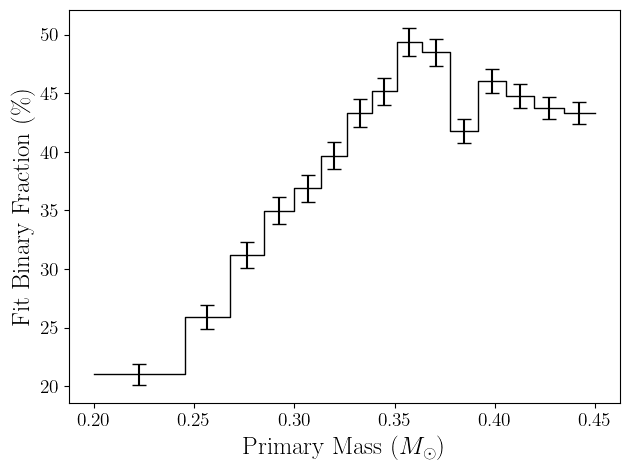

In [43]:
fbs = np.linspace(0.02, 0.98, len(data_likelihoods[0]))
mass_lims_b = np.clip(percs, None, 0.45)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = fbs[np.argmax(data_likelihoods, axis=1)]
sigmas = np.array([cm.fisher_uncertainty(l)[0] for l in data_likelihoods])

plt.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', capsize=5, ecolor='k', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="k", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(f"Fit Binary Fraction (\%)");

plt.tight_layout();
#plt.savefig("./plots/synthbinarity.pdf", dpi=800, transparent=True)

In [86]:
scale = area_in_range((2,4), 4, 1.3)/area_in_range((1,8), 4, 1.3)
area_in_range((5.5,8), 4, 1.3)/area_in_range((1,8), 4, 1.3)

np.float64(0.12468588777490633)

In [ ]:
lowf_likelihoods = []
table_mask = (mdwarfs["flux_ratio_mean"] < 10**(-1.5))
working_reduced_table = reduced_mdwarfs[table_mask]
masses = working_reduced_table["mass"]
bins = 10
percs = np.percentile(masses, np.linspace(0,100,bins+1))
for i in range(bins):
    subset = working_reduced_table[(working_reduced_table["mass"] >= percs[i]) & (working_reduced_table["mass"] < percs[i+1])]
    reduced_memory = subset[["solution_type", "phot_g_mean_mag", "parallax", "mass", "q_max"]]
    model_cube = cm.create_model_cube(grid_shape=(50,35), p_model=(4,1.3), q_model=0)
    fbs, likelihoods_bin = cm.multiplicity(catalogue=reduced_memory, model_cube=model_cube, sc_cube=sc_cube, resolution=1000, 
                                           cutoff=np.exp(-30), scale=5, verbose=True, combine_higher_order=True)
    lowf_likelihoods.append(likelihoods_bin)
    print(fbs[np.argmax(likelihoods_bin)])

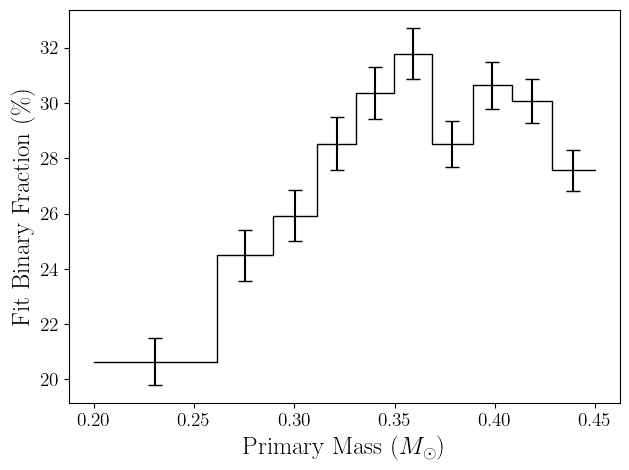

In [59]:
fbs = np.linspace(0.02, 0.98, len(lowf_likelihoods[0]))
mass_lims_b = np.clip(percs, None, 0.45)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = fbs[np.argmax(lowf_likelihoods, axis=1)]
sigmas = np.array([cm.fisher_uncertainty(l)[0] for l in lowf_likelihoods])

plt.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', capsize=5, ecolor='k', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="k", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(f"Fit Binary Fraction (\%)");

plt.tight_layout();
#plt.savefig("./plots/synthbinarity.pdf", dpi=800, transparent=True)

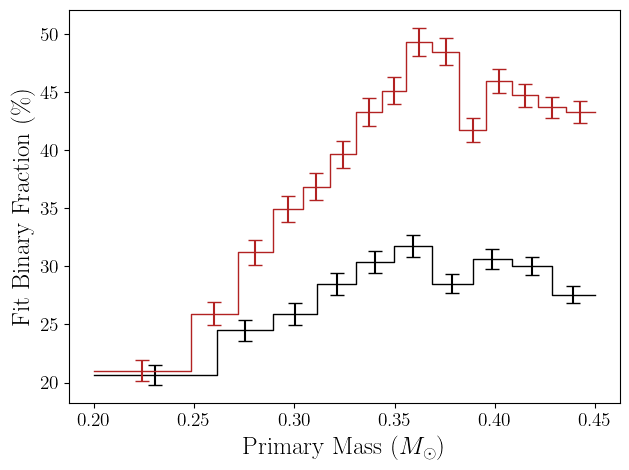

In [62]:
fbs = np.linspace(0.02, 0.98, len(lowf_likelihoods[0]))
bins = 10
percs = np.percentile(masses, np.linspace(0,100,bins+1))
mass_lims_b = np.clip(percs, None, 0.45)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = fbs[np.argmax(lowf_likelihoods, axis=1)]
sigmas = np.array([cm.fisher_uncertainty(l)[0] for l in lowf_likelihoods])

plt.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', capsize=5, ecolor='k', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="k", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(f"Fit Binary Fraction (\%)");

plt.tight_layout();

fbs = np.linspace(0.02, 0.98, len(data_likelihoods[0]))
bins = 15
percs = np.percentile(masses, np.linspace(0,100,bins+1))
mass_lims_b = np.clip(percs, None, 0.45)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = fbs[np.argmax(data_likelihoods, axis=1)]
sigmas = np.array([cm.fisher_uncertainty(l)[0] for l in data_likelihoods])

plt.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', capsize=5, ecolor='firebrick', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="firebrick", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(f"Fit Binary Fraction (\%)");

plt.tight_layout();
#plt.savefig("./plots/synthbinarity.pdf", dpi=800, transparent=True)

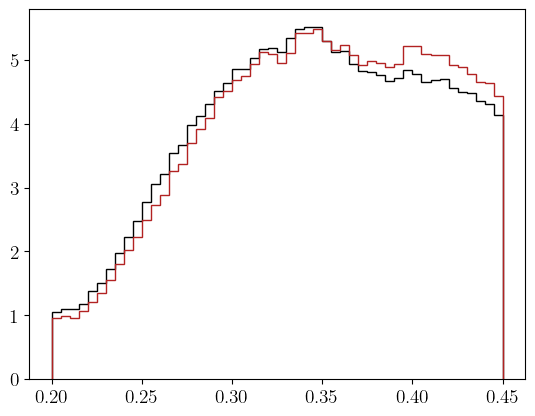

In [61]:
plt.hist(mdwarfs["mass"], bins=50, histtype="step", density=True);
plt.hist(mdwarfs[mdwarfs["flux_ratio_mean"] < 10**(-1.5)]["mass"], bins=50, histtype="step", density=True);

In [65]:
orbit_solutions = Table.read("./data/06_05_26_orbit_solutions.fits", format="fits")

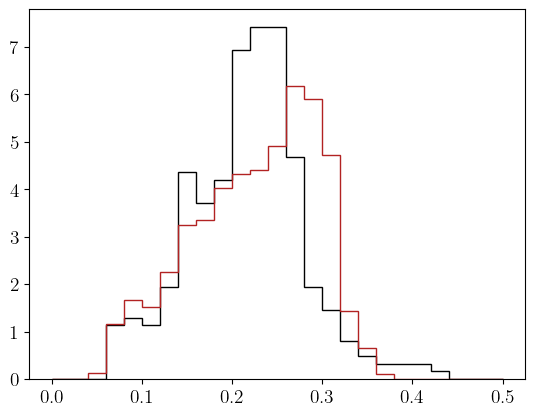

In [84]:
working_orbit_solutions = orbit_solutions[orbit_solutions["flux_ratio_mean"] < 10**(-1.5)]
plt.hist(working_orbit_solutions["m2"]/working_orbit_solutions["mass_single"], bins=25, range=(0,0.5), histtype="step", density=True);
orbs = res[res["solution_type"] == 12]
plt.hist(orbs["m2"]/orbs["mass"], bins=25, range=(0,0.5), histtype="step", density=True);

In [114]:
def adjustment(fb, count, uprate):
    bin_count = fb*count
    single_count = (1-fb)*count

    new_fb = (bin_count*uprate) / (single_count + bin_count*uprate)
    return new_fb
    
def q_max_scaling(catalogue, bins=10):
    bin_counts = np.zeros(bins)
    bin_adjustments = np.zeros(bins)
    
    masses = catalogue["mass"]
    percs = np.percentile(masses, np.linspace(0,100,bins+1))
    for i in range(len(percs)-1):
        objs = catalogue[(masses > percs[i]) & (masses < percs[i+1])]
        print(f"{percs[i]:.3f} to {percs[i+1]:.3f}: mean q_max: {np.mean(objs['q_max'])}")
        bin_counts[i] = len(objs)
        bin_adjustments[i] = np.sum(1/objs["q_max"])/len(objs)
    return bin_counts, bin_adjustments

def extrapolate_q(likelihood_sets, bin_counts, bin_adjustments):
    fbs = np.linspace(0.02, 0.98, len(likelihood_sets[0]))
    dtheta = fbs[1] - fbs[0]
    ind_max = np.argmax(likelihood_sets, axis=1)
    second_derivative = np.array([likelihood_sets[i,ind_max[i] + 1] - 2 * likelihood_sets[i,ind_max[i]] + likelihood_sets[i,ind_max[i] - 1] for i in range(len(likelihood_sets))])/dtheta**2 
    peaks = fbs[np.argmax(likelihood_sets, axis=1)]
    sigma = 1 / np.sqrt(-second_derivative)
    
    adjusted_res = adjustment(peaks, bin_counts, bin_adjustments)
    adjusted_sigma = adjustment(peaks+sigma, bin_counts, bin_adjustments) - adjusted_res
    
    return adjusted_res, adjusted_sigma

In [124]:
adjr15, adjs15 = extrapolate_q(np.array(data_likelihoods), *q_max_scaling(reduced_mdwarfs, bins=15))
adjr15, adjs15

0.200 to 0.245: mean q_max: 0.3675516380114105
0.245 to 0.268: mean q_max: 0.3564754059675298
0.268 to 0.285: mean q_max: 0.347123468440369
0.285 to 0.300: mean q_max: 0.3402649253577198
0.300 to 0.313: mean q_max: 0.33463048142971047
0.313 to 0.326: mean q_max: 0.33030532097461807
0.326 to 0.339: mean q_max: 0.3258596915755673
0.339 to 0.351: mean q_max: 0.3220866742812116
0.351 to 0.364: mean q_max: 0.3192757566227953
0.364 to 0.377: mean q_max: 0.31712250484316634
0.377 to 0.392: mean q_max: 0.3157404748122026
0.392 to 0.405: mean q_max: 0.3155999279046832
0.405 to 0.420: mean q_max: 0.31618081487195226
0.420 to 0.434: mean q_max: 0.31671289249658985
0.434 to 0.450: mean q_max: 0.3169120389683512


(array([0.42076706, 0.49580309, 0.56679051, 0.61253699, 0.63599396,
        0.66571823, 0.70115814, 0.71878049, 0.75341205, 0.74820973,
        0.69454898, 0.72983544, 0.71940933, 0.71032679, 0.70696519]),
 array([0.01302777, 0.01285892, 0.01225176, 0.01181393, 0.01135604,
        0.01078288, 0.01010391, 0.009533  , 0.00877529, 0.00858158,
        0.00889903, 0.00815986, 0.00802123, 0.00783738, 0.00760505]))

In [125]:
adjr10, adjs10 = extrapolate_q(np.array(lowf_likelihoods), *q_max_scaling(working_reduced_table, bins=10))
adjr10, adjs10

0.200 to 0.261: mean q_max: 0.36714701838150576
0.261 to 0.289: mean q_max: 0.34969973892278194
0.289 to 0.311: mean q_max: 0.3386649364718403
0.311 to 0.331: mean q_max: 0.33092825507700685
0.331 to 0.350: mean q_max: 0.3238520454378249
0.350 to 0.369: mean q_max: 0.3188862229486172
0.369 to 0.389: mean q_max: 0.315841165646017
0.389 to 0.409: mean q_max: 0.31524556730439107
0.409 to 0.429: mean q_max: 0.31618403762949443
0.429 to 0.450: mean q_max: 0.3168568330018096


(array([0.4151374 , 0.48126661, 0.50832423, 0.54670162, 0.57367769,
        0.59378699, 0.55825484, 0.58360495, 0.57623197, 0.54569194]),
 array([0.01231455, 0.01224118, 0.01203326, 0.01144844, 0.01079498,
        0.01022486, 0.01008075, 0.00952572, 0.0091965 , 0.00901693]))

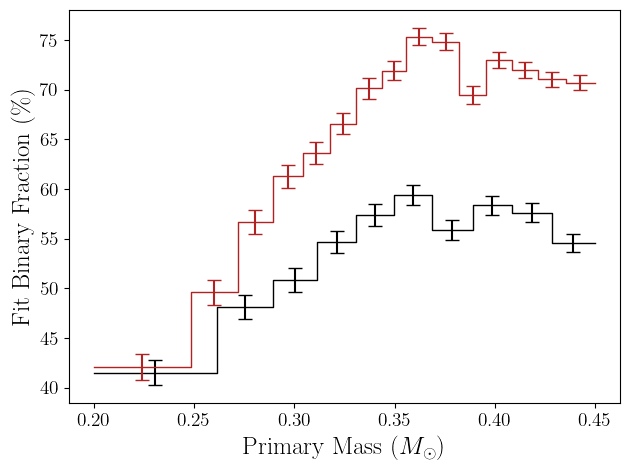

In [126]:
fbs = np.linspace(0.02, 0.98, len(lowf_likelihoods[0]))
bins = 10
percs = np.percentile(masses, np.linspace(0,100,bins+1))
mass_lims_b = np.clip(percs, None, 0.45)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = adjr10
sigmas = adjs10

plt.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', capsize=5, ecolor='k', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="k", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(f"Fit Binary Fraction (\%)");

plt.tight_layout();

fbs = np.linspace(0.02, 0.98, len(data_likelihoods[0]))
bins = 15
percs = np.percentile(masses, np.linspace(0,100,bins+1))
mass_lims_b = np.clip(percs, None, 0.45)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
peaks = adjr15
sigmas = adjs15

plt.errorbar(bin_centers, peaks*100, yerr=(sigmas*100), fmt='none', capsize=5, ecolor='firebrick', zorder=1)
plt.plot(mass_lims_b.repeat(2)[1:-1], (100*peaks).repeat(2), c="firebrick", lw=1, zorder=1);
plt.xlabel(r"Primary Mass $(M_\odot)$");
plt.ylabel(f"Fit Binary Fraction (\%)");

plt.tight_layout();
#plt.savefig("./plots/synthbinarity.pdf", dpi=800, transparent=True)